# Results: Compute-Normalized Model Comparison

This notebook visualizes experimental results comparing different transformer architectures on algorithmic reasoning tasks:
- **Models**: GPT, GPT_Level1, GPT_Level2, UT, UT_Level1, UT_Level2, TRM
- **Tasks**: Addition, Copy, Reverse
- **Key Question**: Which architectures generalize better to longer sequences than seen during training?

## 1. Setup and Imports

In [2]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Style settings for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
})

# Color palette for models
MODEL_COLORS = {
    'gpt': '#1f77b4',
    'gpt_level1': '#ff7f0e', 
    'gpt_level2': '#2ca02c',
    'ut': '#d62728',
    'ut_level1': '#9467bd',
    'ut_level2': '#8c564b',
    'trm': '#e377c2',
}

MODEL_LABELS = {
    'gpt': 'GPT',
    'gpt_level1': 'GPT-L1',
    'gpt_level2': 'GPT-L2',
    'ut': 'UT',
    'ut_level1': 'UT-L1',
    'ut_level2': 'UT-L2',
    'trm': 'TRM',
}

TASK_LABELS = {
    'addition': 'Addition',
    'copy': 'Copy',
    'reverse': 'Reverse',
}

print("Setup complete!")

Setup complete!


## 2. Load Data from W&B

Fetch all runs from the experiment sweep with `compute24_train20` tag.

In [4]:
# Configuration
PROJECT = "pauliusrauba/icml-recursive-llms"
TAG_FILTER = "compute24_train20"  # Matches run names like "gpt_addition_char_compute24_train20"

# Initialize W&B API
api = wandb.Api()

# Fetch all runs from the project
runs = api.runs(PROJECT)

# Filter runs by name pattern (compute24_train20 experiments)
filtered_runs = [r for r in runs if TAG_FILTER in r.name]

In [6]:
print(filtered_runs)

[<Run pauliusrauba/icml-recursive-llms/y200nu1g (crashed)>, <Run pauliusrauba/icml-recursive-llms/w47j6jjv (crashed)>, <Run pauliusrauba/icml-recursive-llms/uxmks7ad (finished)>, <Run pauliusrauba/icml-recursive-llms/4z17spzu (finished)>, <Run pauliusrauba/icml-recursive-llms/ow9g4ska (finished)>, <Run pauliusrauba/icml-recursive-llms/e2cup1vj (finished)>, <Run pauliusrauba/icml-recursive-llms/1fva9upp (finished)>, <Run pauliusrauba/icml-recursive-llms/wal34t3h (finished)>, <Run pauliusrauba/icml-recursive-llms/utl6c9bk (finished)>, <Run pauliusrauba/icml-recursive-llms/rprk2l3b (finished)>, <Run pauliusrauba/icml-recursive-llms/l0sn5wex (finished)>, <Run pauliusrauba/icml-recursive-llms/ueekdlqv (finished)>, <Run pauliusrauba/icml-recursive-llms/ym7yieud (finished)>, <Run pauliusrauba/icml-recursive-llms/9kcjx0ky (finished)>, <Run pauliusrauba/icml-recursive-llms/4i5wel6h (finished)>, <Run pauliusrauba/icml-recursive-llms/zt5xpgin (finished)>, <Run pauliusrauba/icml-recursive-llms/ej8

In [ ]:

summary = json.loads(run1.summary._json_dict)

## 2b. Explore Run History Structure

Let's see what metrics are available in the run history to plan our compute-performance plot.

In [64]:
# Pick one finished run to explore its history structure
sample_run = [r for r in filtered_runs if r.state == 'finished'][0]
print(f"Exploring run: {sample_run.name}")

# Get history
history_df = sample_run.history(pandas=True)
print(f"History shape: {history_df.shape}")
print(f"\nAvailable columns in history:")
for col in sorted(history_df.columns):
    non_null = history_df[col].notna().sum()
    print(f"  {col}: {non_null} values")

Exploring run: gpt_level1_addition_char_compute24_train20


KeyboardInterrupt: 

## 2c. Compute-Performance Frontier

Plot how performance evolves with training compute (FLOPs).

**FLOPs Estimation**: Since we don't log FLOPs directly, we estimate:
```
Training FLOPs ≈ 6 × Parameters × Tokens_processed
Tokens_processed = steps × batch_size × sequence_length
```

The factor of 6 accounts for forward pass (2×) and backward pass (4×) in training.

In [73]:
def estimate_flops(params_millions, steps, batch_size, seq_length):
    """
    Estimate training FLOPs using the Chinchilla approximation.
    FLOPs ≈ 6 * N * D where N=params, D=tokens processed
    """
    params = params_millions * 1e6
    print(steps, batch_size, seq_length)
    tokens = steps * batch_size['value'] * seq_length['value']
    return 6 * params * tokens

def get_run_training_curves(run, task):
    """Extract training curves with estimated FLOPs for a run."""
    config = json.loads(run.config)
    history = run.history(pandas=True, samples=5000)
    
    # Get model parameters (from summary or estimate)
    summary = json.loads(run.summary._json_dict)
    param_count_M = summary.get('model/param_count_M', None)
    
    if param_count_M is None:
        print(f"  Warning: No param count for {run.name}, skipping")
        return None
    
    # Get training config
    batch_size = config.get('batch_size', 64)
    block_size = config.get('block_size', 256)
    
    # Prepare data
    results = []
    
    for _, row in history.iterrows():
        step = row.get('_step', row.get('trainer/global_step', None))
        if step is None or pd.isna(step):
            continue
            
        # Estimate FLOPs at this step
        flops = estimate_flops(param_count_M, step, batch_size, block_size)
        
        entry = {
            'step': step,
            'flops': flops,
            'flops_1e18': flops / 1e18,  # PetaFLOPs
        }
        
        # Get loss metrics
        if 'val_loss' in row and pd.notna(row['val_loss']):
            entry['val_loss'] = row['val_loss']
        if 'train_loss' in row and pd.notna(row['train_loss']):
            entry['train_loss'] = row['train_loss']
            
        # Get task-specific accuracy metrics at different lengths
        for length in [20, 40, 60, 80, 100]:
            key = f'TaskEvaluation/{task}/L{length}/char_acc'
            if key in row and pd.notna(row[key]):
                entry[f'char_acc_L{length}'] = row[key]
                entry[f'error_L{length}'] = 1 - row[key]  # Error = 1 - accuracy
                
        results.append(entry)
    
    return pd.DataFrame(results)

# Collect training curves for all finished runs
all_curves = {}
for run in filtered_runs:
    if run.state != 'finished':
        continue
    
    model, task = parse_run_name(run.name)
    print(f"Loading {run.name}...")
    
    curve_df = get_run_training_curves(run, task)
    if curve_df is not None and len(curve_df) > 0:
        all_curves[run.name] = {
            'model': model,
            'task': task,
            'data': curve_df,
            'config': json.loads(run.config),
            'summary': json.loads(run.summary._json_dict),
        }
        print(f"  ✓ Got {len(curve_df)} data points")

print(f"\n✓ Loaded curves for {len(all_curves)} runs")

Loading gpt_level1_addition_char_compute24_train20...


0.0 {'value': 64} {'value': 256}
1.0 {'value': 64} {'value': 256}
2.0 {'value': 64} {'value': 256}
3.0 {'value': 64} {'value': 256}
4.0 {'value': 64} {'value': 256}
5.0 {'value': 64} {'value': 256}
6.0 {'value': 64} {'value': 256}
7.0 {'value': 64} {'value': 256}
8.0 {'value': 64} {'value': 256}
9.0 {'value': 64} {'value': 256}
10.0 {'value': 64} {'value': 256}
11.0 {'value': 64} {'value': 256}
12.0 {'value': 64} {'value': 256}
13.0 {'value': 64} {'value': 256}
14.0 {'value': 64} {'value': 256}
15.0 {'value': 64} {'value': 256}
16.0 {'value': 64} {'value': 256}
17.0 {'value': 64} {'value': 256}
18.0 {'value': 64} {'value': 256}
19.0 {'value': 64} {'value': 256}
20.0 {'value': 64} {'value': 256}
21.0 {'value': 64} {'value': 256}
22.0 {'value': 64} {'value': 256}
23.0 {'value': 64} {'value': 256}
24.0 {'value': 64} {'value': 256}
25.0 {'value': 64} {'value': 256}
26.0 {'value': 64} {'value': 256}
27.0 {'value': 64} {'value': 256}
28.0 {'value': 64} {'value': 256}
29.0 {'value': 64} {'val

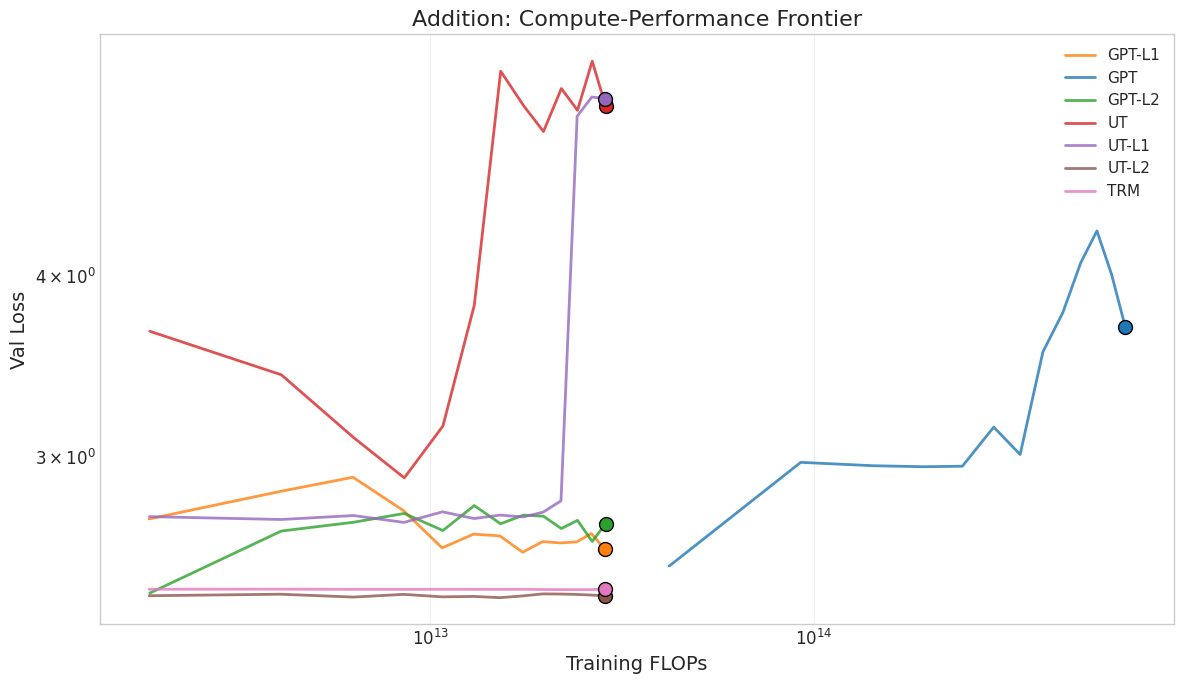

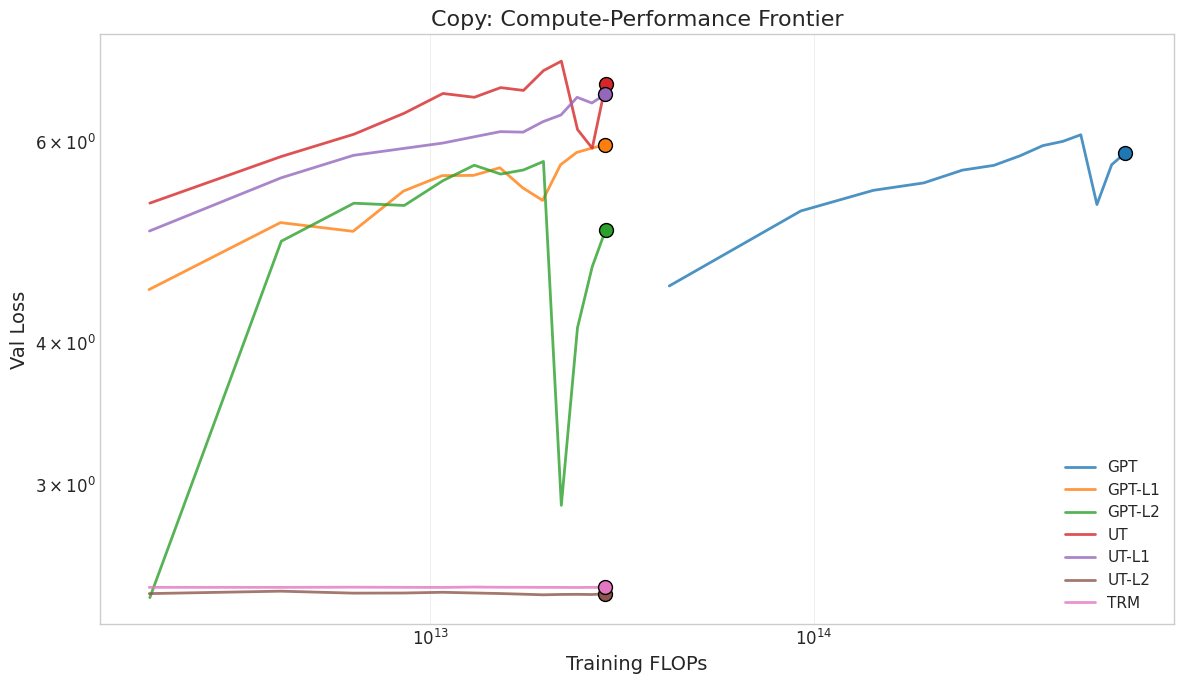

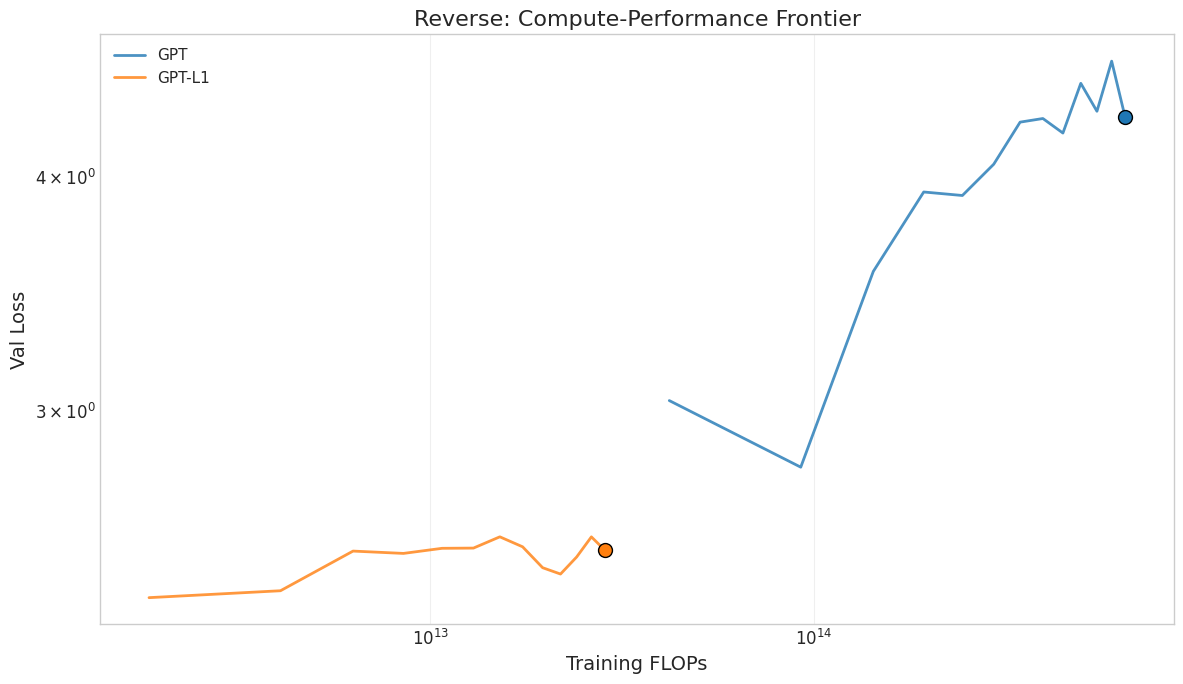

In [74]:
def plot_compute_performance_frontier(all_curves, task_filter, metric='val_loss', 
                                       use_error=False, length=None):
    """
    Plot compute-performance frontier for a specific task.
    
    Args:
        all_curves: dict of run data
        task_filter: which task to plot ('addition', 'copy', 'reverse')
        metric: 'val_loss', 'train_loss', or 'char_acc'
        use_error: if True and metric='char_acc', plot error (1-acc) instead
        length: for char_acc, which evaluation length to use (20, 40, 60, 80, 100)
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for run_name, run_data in all_curves.items():
        if run_data['task'] != task_filter:
            continue
            
        model = run_data['model']
        curve_df = run_data['data']
        
        # Determine y-axis metric
        if metric == 'char_acc' and length:
            y_col = f'error_L{length}' if use_error else f'char_acc_L{length}'
            y_label = f'Error (1 - Char Acc) @ L={length}' if use_error else f'Char Accuracy @ L={length}'
        else:
            y_col = metric
            y_label = metric.replace('_', ' ').title()
        
        if y_col not in curve_df.columns:
            continue
            
        # Filter valid data points
        valid = curve_df[['flops', y_col]].dropna()
        if len(valid) == 0:
            continue
        
        color = MODEL_COLORS.get(model, '#333333')
        label = MODEL_LABELS.get(model, model)
        
        ax.plot(valid['flops'], valid[y_col], 
                label=label, color=color, linewidth=2, alpha=0.8)
        
        # Mark final point
        ax.scatter(valid['flops'].iloc[-1], valid[y_col].iloc[-1], 
                   color=color, s=100, zorder=5, edgecolors='black')
    
    ax.set_xscale('log')
    if use_error or 'loss' in metric:
        ax.set_yscale('log')
    
    ax.set_xlabel('Training FLOPs')
    ax.set_ylabel(y_label)
    ax.set_title(f'{TASK_LABELS.get(task_filter, task_filter)}: Compute-Performance Frontier')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    return fig, ax

# Plot for each task - using validation loss
for task in ['addition', 'copy', 'reverse']:
    task_runs = [k for k, v in all_curves.items() if v['task'] == task]
    if task_runs:
        fig, ax = plot_compute_performance_frontier(all_curves, task, metric='val_loss')
        plt.tight_layout()
        plt.savefig(f'compute_frontier_loss_{task}.pdf', bbox_inches='tight', dpi=150)
        plt.show()

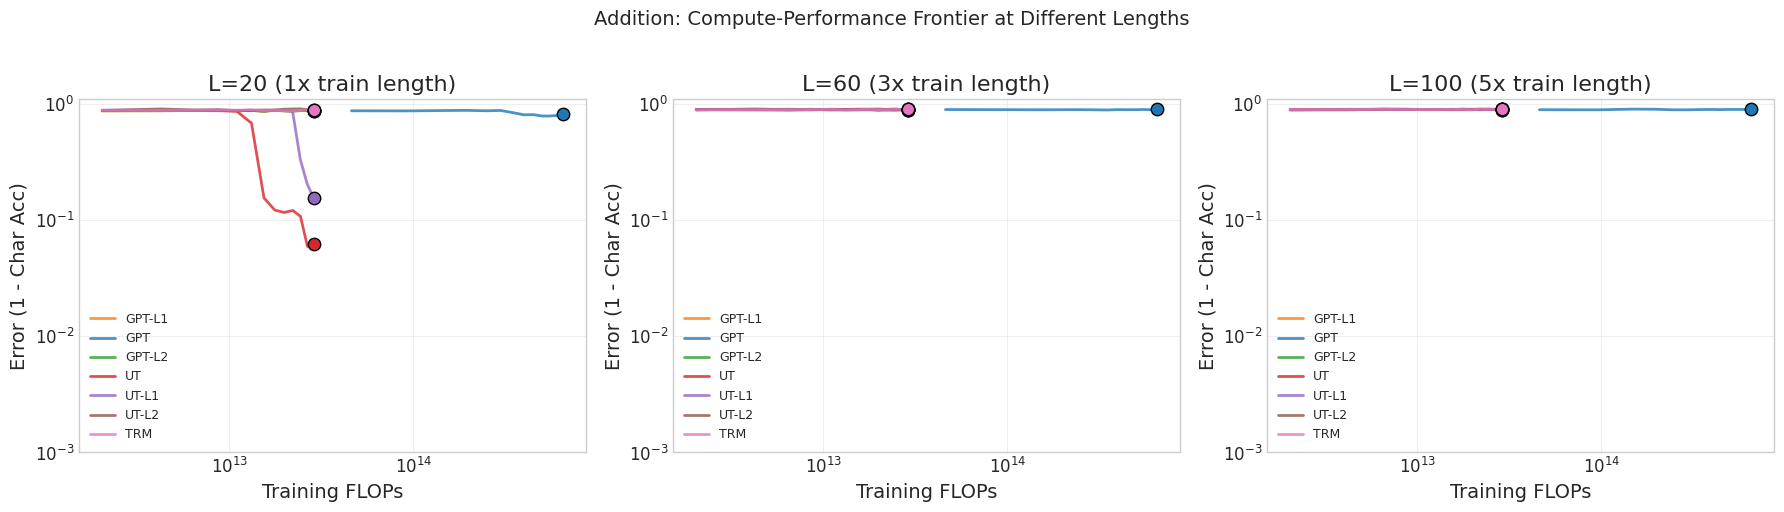

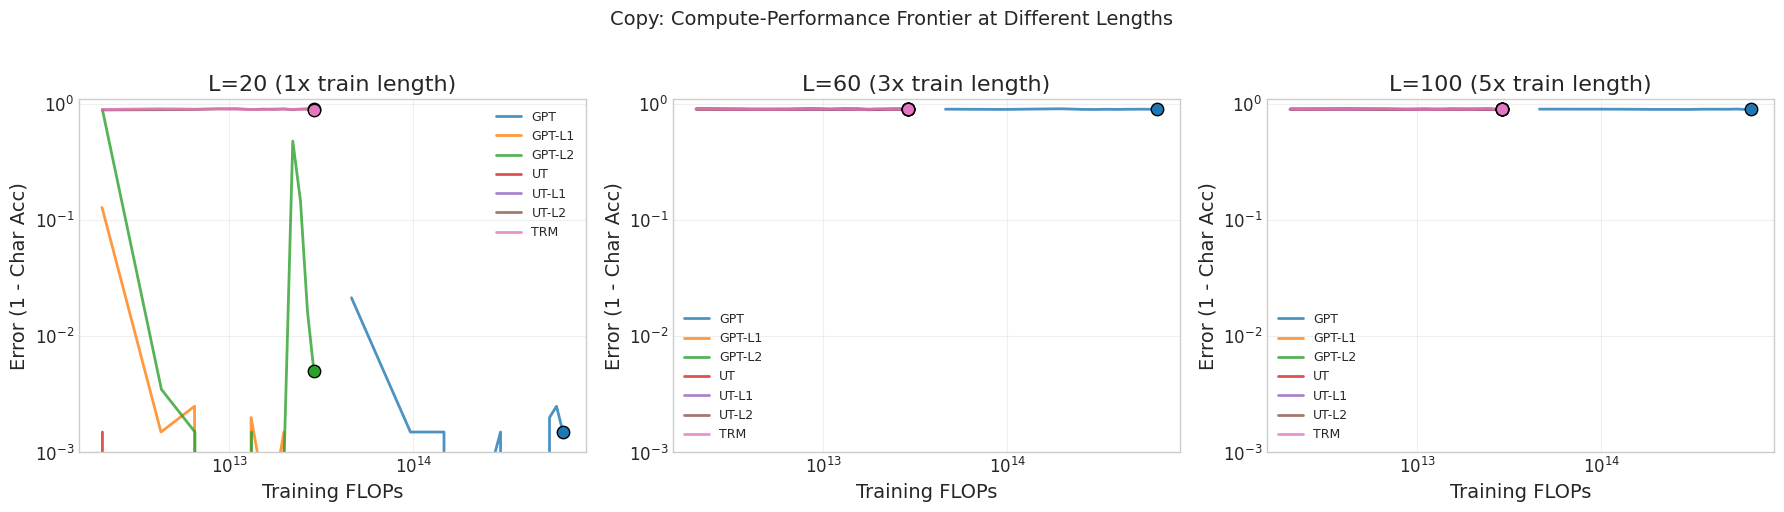

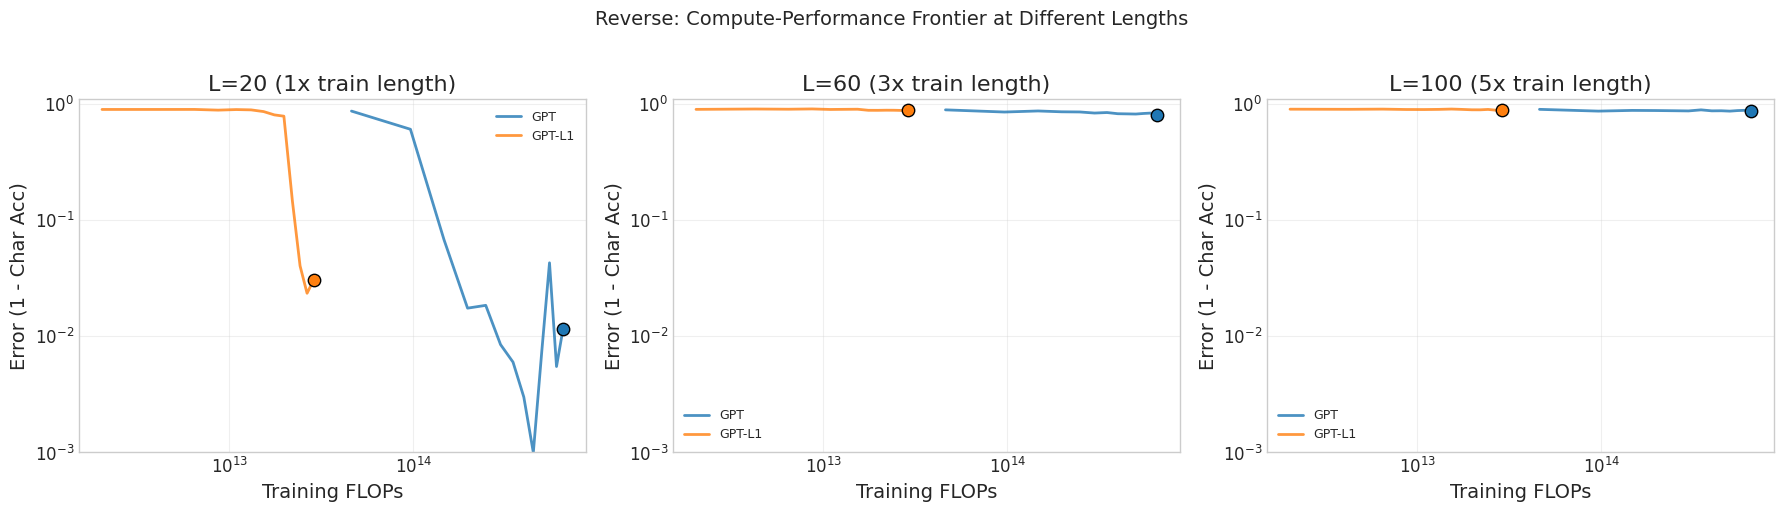

In [75]:
# Plot compute-performance frontier using character error at different lengths
# This shows how models reach low error with increasing compute

for task in ['addition', 'copy', 'reverse']:
    task_runs = [k for k, v in all_curves.items() if v['task'] == task]
    if not task_runs:
        continue
    
    # Create subplots for different evaluation lengths
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, length in zip(axes, [20, 60, 100]):
        for run_name, run_data in all_curves.items():
            if run_data['task'] != task:
                continue
                
            model = run_data['model']
            curve_df = run_data['data']
            
            y_col = f'error_L{length}'
            if y_col not in curve_df.columns:
                continue
                
            valid = curve_df[['flops', y_col]].dropna()
            if len(valid) == 0:
                continue
            
            color = MODEL_COLORS.get(model, '#333333')
            label = MODEL_LABELS.get(model, model)
            
            ax.plot(valid['flops'], valid[y_col], 
                    label=label, color=color, linewidth=2, alpha=0.8)
            ax.scatter(valid['flops'].iloc[-1], valid[y_col].iloc[-1], 
                       color=color, s=80, zorder=5, edgecolors='black')
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Training FLOPs')
        ax.set_ylabel('Error (1 - Char Acc)')
        ratio = length // 20
        ax.set_title(f'L={length} ({ratio}x train length)')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([1e-3, 1.1])  # Error from 0.1% to 100%
    
    fig.suptitle(f'{TASK_LABELS.get(task, task)}: Compute-Performance Frontier at Different Lengths', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'compute_frontier_error_{task}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

In [76]:
# Create a summary showing final error at different compute levels
# This helps identify which models are most compute-efficient

def get_frontier_summary(all_curves, length=100):
    """Get final performance for each model-task combination."""
    results = []
    
    for run_name, run_data in all_curves.items():
        model = run_data['model']
        task = run_data['task']
        curve_df = run_data['data']
        summary = run_data['summary']
        
        # Get final values
        final_row = curve_df.dropna(subset=['flops']).iloc[-1] if len(curve_df) > 0 else None
        if final_row is None:
            continue
            
        error_col = f'error_L{length}'
        acc_col = f'char_acc_L{length}'
        
        results.append({
            'Model': MODEL_LABELS.get(model, model),
            'model_key': model,
            'Task': TASK_LABELS.get(task, task),
            'task_key': task,
            'Final FLOPs': final_row['flops'],
            'Final FLOPs (1e18)': final_row['flops'] / 1e18,
            f'Final Error L{length}': final_row.get(error_col, np.nan),
            f'Final Acc L{length}': final_row.get(acc_col, np.nan),
            'Params (M)': summary.get('model/param_count_M', np.nan),
        })
    
    return pd.DataFrame(results)

# Summary table
frontier_summary = get_frontier_summary(all_curves, length=100)
if not frontier_summary.empty:
    print("Compute-Performance Summary (L=100, 5x training length):\n")
    display(frontier_summary.sort_values(['Task', 'Final Error L100']))
else:
    print("No data available for summary.")

Compute-Performance Summary (L=100, 5x training length):



,Model,model_key,Task,task_key,Final FLOPs,Final FLOPs (1e18),Final Error L100,Final Acc L100,Params (M)
4,UT-L1,ut_level1,Addition,addition,2.877571e+13,0.000029,0.895842,0.104158,1.888527
3,UT,ut,Addition,addition,2.884007e+13,0.000029,0.897129,0.102871,1.892751
1,GPT,gpt,Addition,addition,6.501576e+14,0.000650,0.900990,0.099010,42.669326
2,GPT-L2,gpt_level2,Addition,addition,2.883421e+13,0.000029,0.902970,0.097030,1.892366
6,TRM,trm,Addition,addition,2.872890e+13,0.000029,0.903069,0.096931,1.885455
0,GPT-L1,gpt_level1,Addition,addition,2.869378e+13,0.000029,0.904257,0.095743,1.883150
5,UT-L2,ut_level2,Addition,addition,2.872890e+13,0.000029,0.905941,0.094059,1.885455
10,UT,ut,Copy,copy,2.884007e+13,0.000029,0.899200,0.100800,1.892751
7,GPT,gpt,Copy,copy,6.501576e+14,0.000650,0.899300,0.100700,42.669326
8,GPT-L1,gpt_level1,Copy,copy,2.869378e+13,0.000029,0.900700,0.099300,1.883150


In [58]:
summary

{'TaskEvaluation/addition/L100/char_acc': 0.09574257425742574,
 'TaskEvaluation/addition/L100/first_char_acc': 0.56,
 'TaskEvaluation/addition/L100/last_char_acc': 0.12,
 'TaskEvaluation/addition/L100/pos_q1_acc': 0.1104,
 'TaskEvaluation/addition/L100/pos_q2_acc': 0.0892,
 'TaskEvaluation/addition/L100/pos_q3_acc': 0.0888,
 'TaskEvaluation/addition/L100/pos_q4_acc': 0.09461538461538462,
 'TaskEvaluation/addition/L100/seq_acc': 0,
 'TaskEvaluation/addition/L20/char_acc': 0.13047619047619047,
 'TaskEvaluation/addition/L20/first_char_acc': 0.75,
 'TaskEvaluation/addition/L20/last_char_acc': 0.06,
 'TaskEvaluation/addition/L20/pos_q1_acc': 0.232,
 'TaskEvaluation/addition/L20/pos_q2_acc': 0.104,
 'TaskEvaluation/addition/L20/pos_q3_acc': 0.086,
 'TaskEvaluation/addition/L20/pos_q4_acc': 0.105,
 'TaskEvaluation/addition/L20/seq_acc': 0,
 'TaskEvaluation/addition/L40/char_acc': 0.10560975609756096,
 'TaskEvaluation/addition/L40/first_char_acc': 0.42,
 'TaskEvaluation/addition/L40/last_char_

In [45]:
import json

def parse_run_name(name):
    """Parse run name like 'gpt_addition_char_compute24_train20' into components."""
    parts = name.split('_')
    # Handle model names with underscores (gpt_level1, ut_level2, etc.)
    if 'level1' in parts or 'level2' in parts:
        model = '_'.join(parts[:2])
        task_parts = parts[2:]
    else:
        model = parts[0]
        task_parts = parts[1:]
    
    # Extract task (e.g., 'addition_char' -> 'addition')
    task = task_parts[0] if task_parts else 'unknown'
    
    return model, task

def extract_final_metrics(run):
    """Extract final evaluation metrics from a run."""
    # Get summary as a proper dict
    summary = json.loads(run.summary._json_dict)
    
    # Get config as a proper dict (W&B config objects need explicit conversion)
    config = json.loads(run.config)
    
    model, task = parse_run_name(run.name)
    
    metrics = {
        'run_id': run.id,
        'run_name': run.name,
        'model': model,
        'task': task,
        'state': run.state,
    }
    
    # Add config info
    metrics['n_layer'] = config.get('n_layer', None)
    metrics['n_embd'] = config.get('n_embd', None)
    metrics['compute_budget'] = config.get('compute_budget', None)
    metrics['algo_train_len'] = config.get('algo_train_len', None)
    
    # Extract final values for each eval length metric
    eval_lengths = [20, 40, 60, 80, 100]
    for length in eval_lengths:
        for metric_name in ['char_acc', 'seq_acc', 'first_char_acc', 'last_char_acc']:
            key = f'TaskEvaluation/{task}/L{length}/{metric_name}'
            if key in summary:
                metrics[f'L{length}_{metric_name}'] = summary[key]
    
    # Add training metrics
    if 'val_loss' in summary:
        metrics['final_val_loss'] = summary['val_loss']
    if 'train_loss' in summary:
        metrics['final_train_loss'] = summary['train_loss']
    if 'model/param_count_M' in summary:
        metrics['param_count_M'] = summary['model/param_count_M']
        
    return metrics

# Extract metrics from all runs (skip non-finished runs)
all_metrics = []
for run in filtered_runs:
    if run.state != 'finished':
        print(f"  Skipping {run.name} (state: {run.state})")
        continue
    try:
        metrics = extract_final_metrics(run)
        all_metrics.append(metrics)
        print(f"  ✓ Processed: {run.name}")
    except Exception as e:
        print(f"  ✗ Error processing {run.name}: {e}")

# Create DataFrame
df = pd.DataFrame(all_metrics)
print(f"\n✓ Loaded {len(df)} runs into DataFrame")
df.head()

  Skipping gpt_level1_addition_char_compute24_train20 (state: crashed)
  Skipping gpt_addition_char_compute24_train20 (state: crashed)
  ✓ Processed: gpt_level1_addition_char_compute24_train20
  ✓ Processed: gpt_addition_char_compute24_train20
  ✓ Processed: gpt_level2_addition_char_compute24_train20
  ✓ Processed: ut_addition_char_compute24_train20
  ✓ Processed: ut_level1_addition_char_compute24_train20
  ✓ Processed: ut_level2_addition_char_compute24_train20
  ✓ Processed: trm_addition_char_compute24_train20
  ✓ Processed: gpt_copy_char_compute24_train20
  ✓ Processed: gpt_level1_copy_char_compute24_train20
  ✓ Processed: gpt_level2_copy_char_compute24_train20
  ✓ Processed: ut_copy_char_compute24_train20
  ✓ Processed: ut_level1_copy_char_compute24_train20
  ✓ Processed: ut_level2_copy_char_compute24_train20
  ✓ Processed: trm_copy_char_compute24_train20
  ✓ Processed: gpt_reverse_char_compute24_train20
  ✓ Processed: gpt_level1_reverse_char_compute24_train20
  Skipping gpt_level2_

,run_id,run_name,model,task,state,n_layer,n_embd,compute_budget,algo_train_len,L20_char_acc,...,L80_seq_acc,L80_first_char_acc,L80_last_char_acc,L100_char_acc,L100_seq_acc,L100_first_char_acc,L100_last_char_acc,final_val_loss,final_train_loss,param_count_M
0,uxmks7ad,gpt_level1_addition_char_compute24_train20,gpt_level1,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.130476,...,0,0.50,0.10,0.095743,0,0.56,0.12,2.592180,2.174299,1.883150
1,4z17spzu,gpt_addition_char_compute24_train20,gpt,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.181429,...,0,0.43,0.10,0.099010,0,0.53,0.13,3.690795,1.760740,42.669326
2,ow9g4ska,gpt_level2_addition_char_compute24_train20,gpt_level2,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.117143,...,0,0.49,0.09,0.097030,0,0.54,0.12,2.699477,2.184716,1.892366
3,e2cup1vj,ut_addition_char_compute24_train20,ut,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.937619,...,0,0.25,0.10,0.102871,0,0.21,0.09,5.235057,1.647133,1.892751
4,1fva9upp,ut_level1_addition_char_compute24_train20,ut_level1,addition,finished,{'value': 12},{'value': 384},{'value': 24},{'value': 20},0.844762,...,0,0.53,0.06,0.104158,0,0.50,0.14,5.300398,1.772250,1.888527


In [56]:
df

,run_id,run_name,model,task,state,n_layer,n_embd,compute_budget,algo_train_len,L20_char_acc,...,L80_seq_acc,L80_first_char_acc,L80_last_char_acc,L100_char_acc,L100_seq_acc,L100_first_char_acc,L100_last_char_acc,final_val_loss,final_train_loss,param_count_M
0,uxmks7ad,gpt_level1_addition_char_compute24_train20,gpt_level1,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.130476,...,0,0.50,0.10,0.095743,0,0.56,0.12,2.592180,2.174299,1.883150
1,4z17spzu,gpt_addition_char_compute24_train20,gpt,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.181429,...,0,0.43,0.10,0.099010,0,0.53,0.13,3.690795,1.760740,42.669326
2,ow9g4ska,gpt_level2_addition_char_compute24_train20,gpt_level2,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.117143,...,0,0.49,0.09,0.097030,0,0.54,0.12,2.699477,2.184716,1.892366
3,e2cup1vj,ut_addition_char_compute24_train20,ut,addition,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.937619,...,0,0.25,0.10,0.102871,0,0.21,0.09,5.235057,1.647133,1.892751
4,1fva9upp,ut_level1_addition_char_compute24_train20,ut_level1,addition,finished,{'value': 12},{'value': 384},{'value': 24},{'value': 20},0.844762,...,0,0.53,0.06,0.104158,0,0.50,0.14,5.300398,1.772250,1.888527
5,wal34t3h,ut_level2_addition_char_compute24_train20,ut_level2,addition,finished,{'value': 4},{'value': 384},{'value': 24},{'value': 20},0.122857,...,0,0.44,0.08,0.094059,0,0.49,0.02,2.406965,2.442384,1.885455
6,utl6c9bk,trm_addition_char_compute24_train20,trm,addition,finished,{'value': 4},{'value': 384},{'value': 24},{'value': 20},0.110952,...,0,0.50,0.10,0.096931,0,0.55,0.07,2.433445,2.457192,1.885455
7,rprk2l3b,gpt_copy_char_compute24_train20,gpt,copy,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.998500,...,0,0.17,0.13,0.100700,0,0.14,0.18,5.872506,1.188946,42.669326
8,l0sn5wex,gpt_level1_copy_char_compute24_train20,gpt_level1,copy,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.999500,...,0,0.17,0.13,0.099300,0,0.13,0.17,5.969801,1.188902,1.883150
9,ueekdlqv,gpt_level2_copy_char_compute24_train20,gpt_level2,copy,finished,{'value': 24},{'value': 384},{'value': 24},{'value': 20},0.995000,...,0,0.17,0.13,0.098900,0,0.14,0.17,5.027510,1.207011,1.892366


## 3. Length Generalization Analysis

How well do models generalize from training length (L=20) to longer sequences?

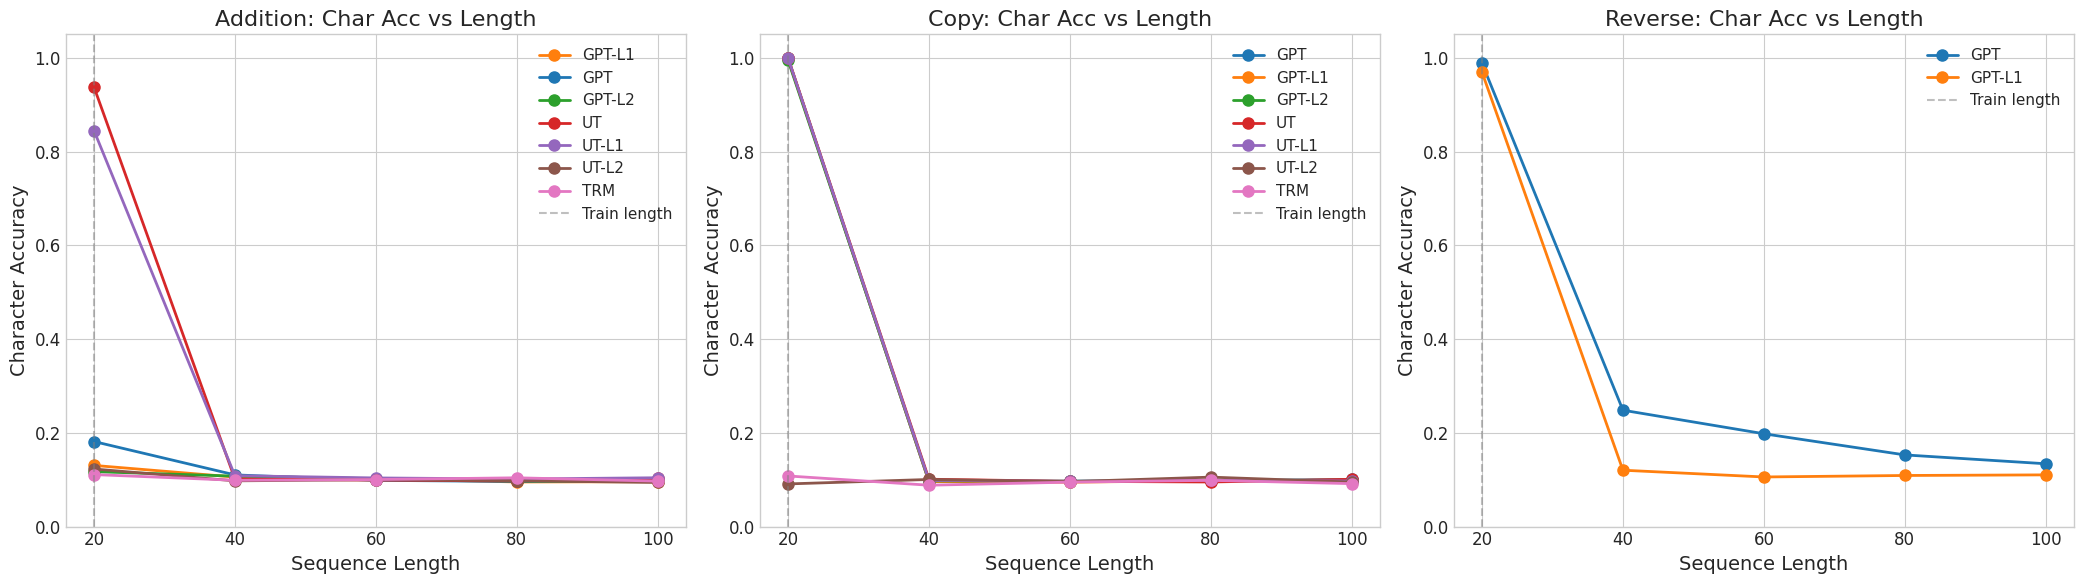

In [46]:
def plot_length_generalization(df, task, metric='char_acc', ax=None):
    """
    Plot character accuracy vs sequence length for all models on a given task.
    
    This shows how models degrade (or not) when evaluated on sequences longer than training.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    task_df = df[df['task'] == task].copy()
    lengths = [20, 40, 60, 80, 100]
    
    for model in task_df['model'].unique():
        model_row = task_df[task_df['model'] == model].iloc[0]
        
        # Extract accuracy at each length
        accs = []
        for L in lengths:
            col = f'L{L}_{metric}'
            if col in model_row and pd.notna(model_row[col]):
                accs.append(model_row[col])
            else:
                accs.append(np.nan)
        
        color = MODEL_COLORS.get(model, '#333333')
        label = MODEL_LABELS.get(model, model)
        ax.plot(lengths, accs, 'o-', label=label, color=color, linewidth=2, markersize=8)
    
    ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='Train length')
    ax.set_xlabel('Sequence Length')
    ax.set_ylabel('Character Accuracy' if metric == 'char_acc' else metric.replace('_', ' ').title())
    ax.set_title(f'{TASK_LABELS.get(task, task)}: {metric.replace("_", " ").title()} vs Length')
    ax.legend(loc='best')
    ax.set_ylim([0, 1.05])
    ax.set_xticks(lengths)
    
    return ax

# Create subplots for each task
tasks = df['task'].unique()
n_tasks = len(tasks)

if n_tasks > 0:
    fig, axes = plt.subplots(1, n_tasks, figsize=(7*n_tasks, 6))
    if n_tasks == 1:
        axes = [axes]
    
    for ax, task in zip(axes, sorted(tasks)):
        plot_length_generalization(df, task, metric='char_acc', ax=ax)
    
    plt.tight_layout()
    plt.savefig('length_generalization_char_acc.pdf', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("No tasks found in data. Make sure experiments have completed.")

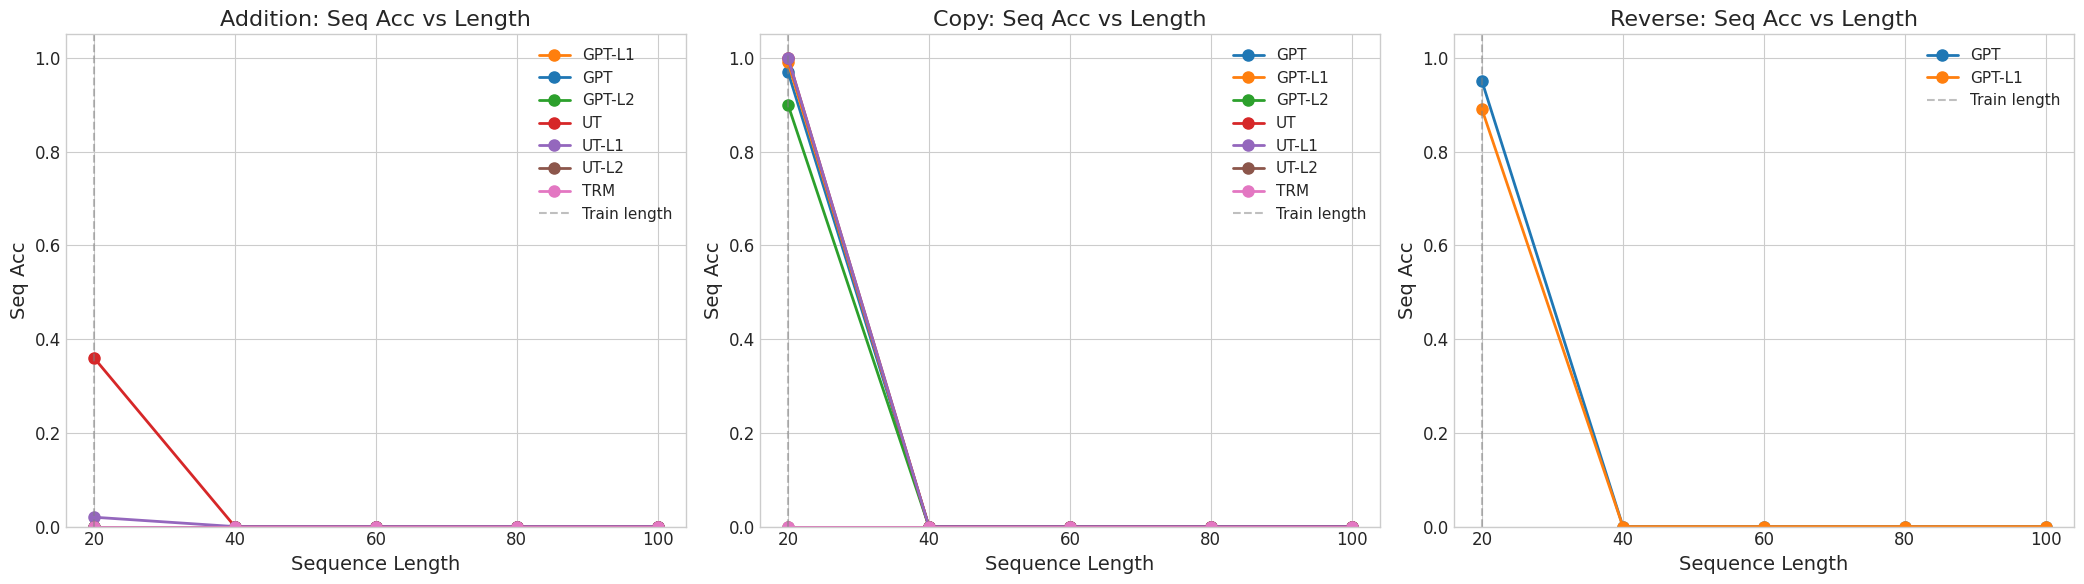

In [47]:
# Same plot for sequence accuracy (exact match)
if n_tasks > 0:
    fig, axes = plt.subplots(1, n_tasks, figsize=(7*n_tasks, 6))
    if n_tasks == 1:
        axes = [axes]
    
    for ax, task in zip(axes, sorted(tasks)):
        plot_length_generalization(df, task, metric='seq_acc', ax=ax)
    
    plt.tight_layout()
    plt.savefig('length_generalization_seq_acc.pdf', bbox_inches='tight', dpi=150)
    plt.show()

## 4. Model Comparison Heatmaps

Compare models across tasks at different generalization ratios (L/L_train).

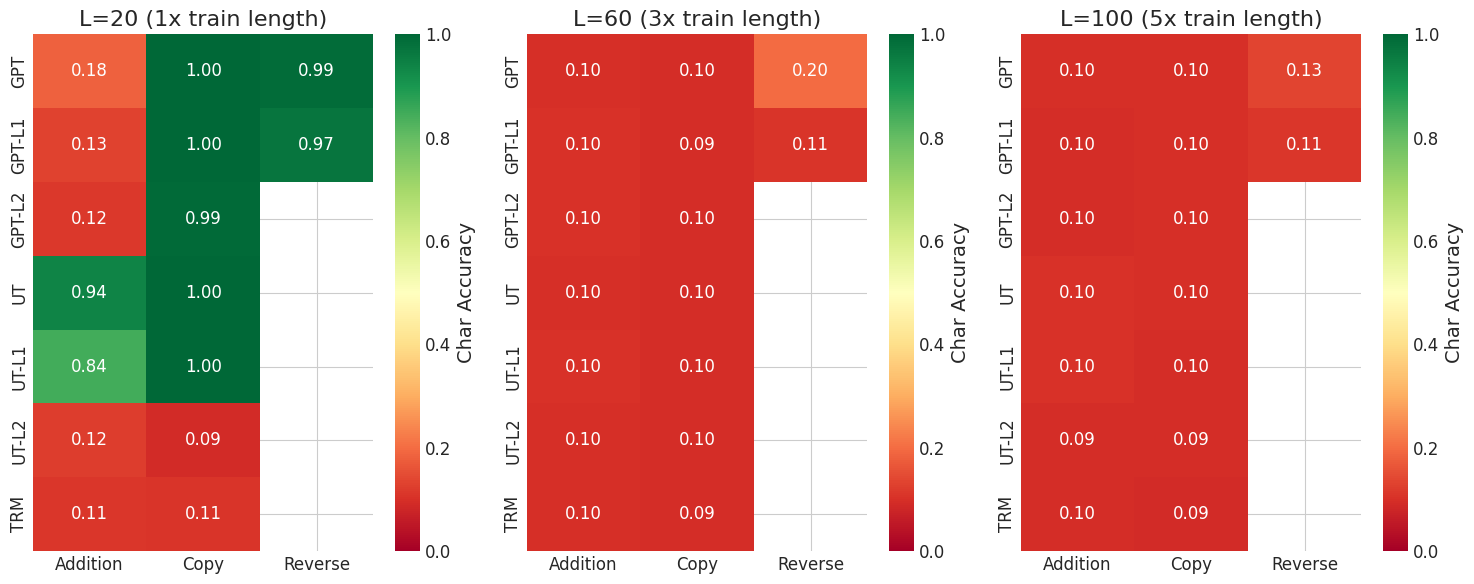

In [48]:
def create_heatmap_data(df, length, metric='char_acc'):
    """Create pivot table for heatmap: models x tasks."""
    col = f'L{length}_{metric}'
    
    if col not in df.columns:
        return None
    
    pivot = df.pivot_table(
        values=col,
        index='model',
        columns='task',
        aggfunc='mean'
    )
    
    # Reorder models in a logical order
    model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
    pivot = pivot.reindex([m for m in model_order if m in pivot.index])
    
    # Rename for display
    pivot.index = [MODEL_LABELS.get(m, m) for m in pivot.index]
    pivot.columns = [TASK_LABELS.get(t, t) for t in pivot.columns]
    
    return pivot

# Create heatmaps at different lengths
lengths_to_plot = [20, 60, 100]  # 1x, 3x, 5x training length

fig, axes = plt.subplots(1, len(lengths_to_plot), figsize=(5*len(lengths_to_plot), 6))

for ax, length in zip(axes, lengths_to_plot):
    pivot = create_heatmap_data(df, length, metric='char_acc')
    if pivot is not None and not pivot.empty:
        sns.heatmap(
            pivot, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            vmin=0, 
            vmax=1,
            ax=ax,
            cbar_kws={'label': 'Char Accuracy'}
        )
        ratio = length // 20
        ax.set_title(f'L={length} ({ratio}x train length)')
    else:
        ax.text(0.5, 0.5, f'No data for L={length}', ha='center', va='center')
        ax.set_title(f'L={length}')

plt.tight_layout()
plt.savefig('model_task_heatmaps.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 5. Generalization Degradation Analysis

Measure how quickly accuracy degrades as sequences get longer.

/tmp/ipykernel_342381/2666319315.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'auc': np.trapz(accs, lengths) / (lengths[-1] - lengths[0]),  # Normalized AUC


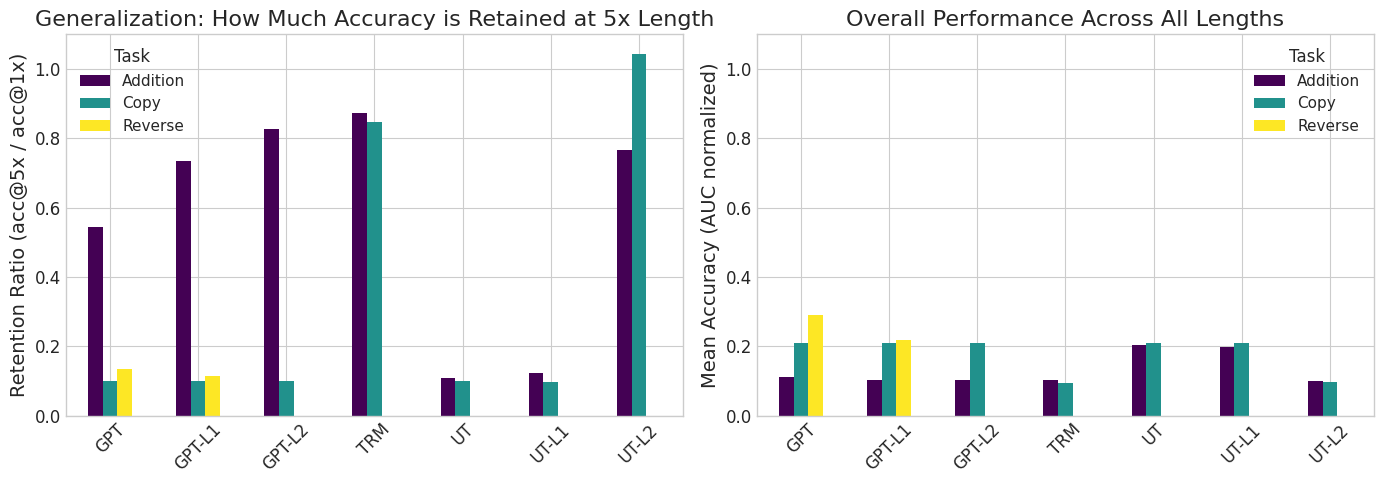

In [52]:
def compute_degradation_metrics(df, metric='char_acc'):
    """
    Compute generalization metrics:
    - acc_at_1x: Accuracy at training length (baseline)
    - acc_at_5x: Accuracy at 5x training length
    - degradation: How much accuracy drops from 1x to 5x
    - area_under_curve: Total area under the acc vs length curve (higher = better generalization)
    """
    results = []
    lengths = [20, 40, 60, 80, 100]
    
    for _, row in df.iterrows():
        accs = []
        for L in lengths:
            col = f'L{L}_{metric}'
            if col in row and pd.notna(row[col]):
                accs.append(row[col])
            else:
                accs.append(np.nan)
        
        if len(accs) >= 2 and not np.isnan(accs[0]) and not np.isnan(accs[-1]):
            results.append({
                'model': row['model'],
                'task': row['task'],
                'acc_at_1x': accs[0],  # L=20
                'acc_at_5x': accs[-1],  # L=100
                'degradation': accs[0] - accs[-1],  # Higher = worse generalization
                'auc': np.trapz(accs, lengths) / (lengths[-1] - lengths[0]),  # Normalized AUC
                'retention_ratio': accs[-1] / max(accs[0], 1e-6),  # What fraction of acc is retained at 5x
            })
    
    return pd.DataFrame(results)

deg_df = compute_degradation_metrics(df, metric='char_acc')

if not deg_df.empty:
    # Plot degradation by model
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Retention ratio (higher is better)
    ax1 = axes[0]
    retention_pivot = deg_df.pivot_table(values='retention_ratio', index='model', columns='task')
    if not retention_pivot.empty:
        retention_pivot.index = [MODEL_LABELS.get(m, m) for m in retention_pivot.index]
        retention_pivot.columns = [TASK_LABELS.get(t, t) for t in retention_pivot.columns]
        retention_pivot.plot(kind='bar', ax=ax1, colormap='viridis')
        ax1.set_ylabel('Retention Ratio (acc@5x / acc@1x)')
        ax1.set_title('Generalization: How Much Accuracy is Retained at 5x Length')
        ax1.set_ylim([0, 1.1])
        ax1.legend(title='Task')
        ax1.tick_params(axis='x', rotation=45)
    
    # Right: Area under curve (higher is better)
    ax2 = axes[1]
    auc_pivot = deg_df.pivot_table(values='auc', index='model', columns='task')
    if not auc_pivot.empty:
        auc_pivot.index = [MODEL_LABELS.get(m, m) for m in auc_pivot.index]
        auc_pivot.columns = [TASK_LABELS.get(t, t) for t in auc_pivot.columns]
        auc_pivot.plot(kind='bar', ax=ax2, colormap='viridis')
        ax2.set_ylabel('Mean Accuracy (AUC normalized)')
        ax2.set_title('Overall Performance Across All Lengths')
        ax2.set_ylim([0, 1.1])
        ax2.legend(title='Task')
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('degradation_analysis.pdf', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Not enough data for degradation analysis.")

## 6. Parameter Efficiency Analysis

Compare accuracy relative to model size (compute is normalized, but parameter count varies).

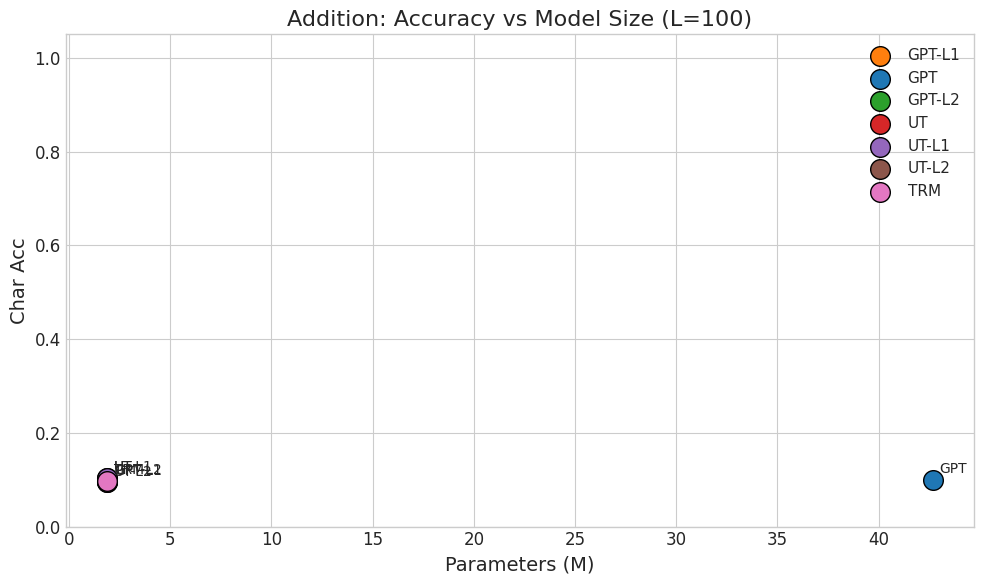

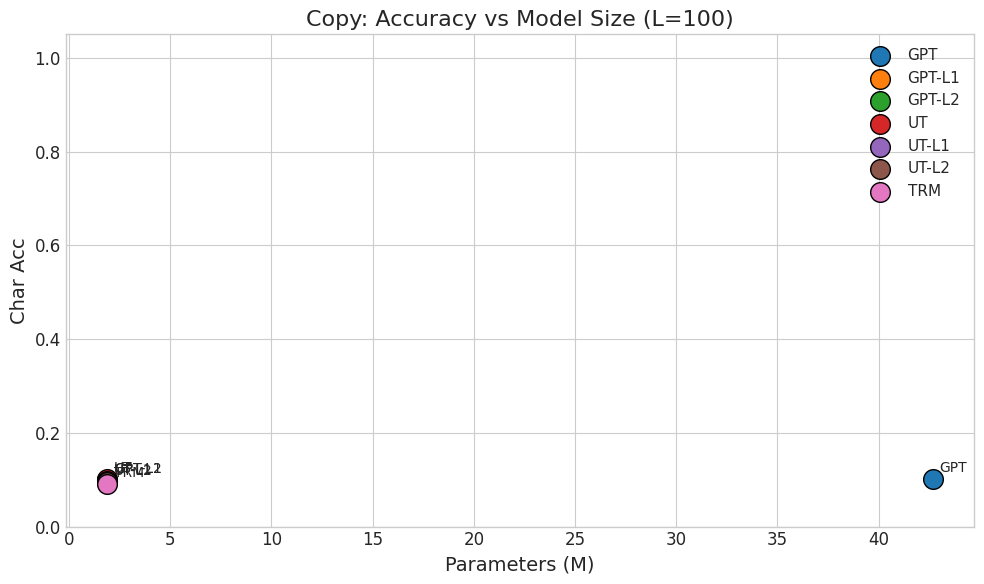

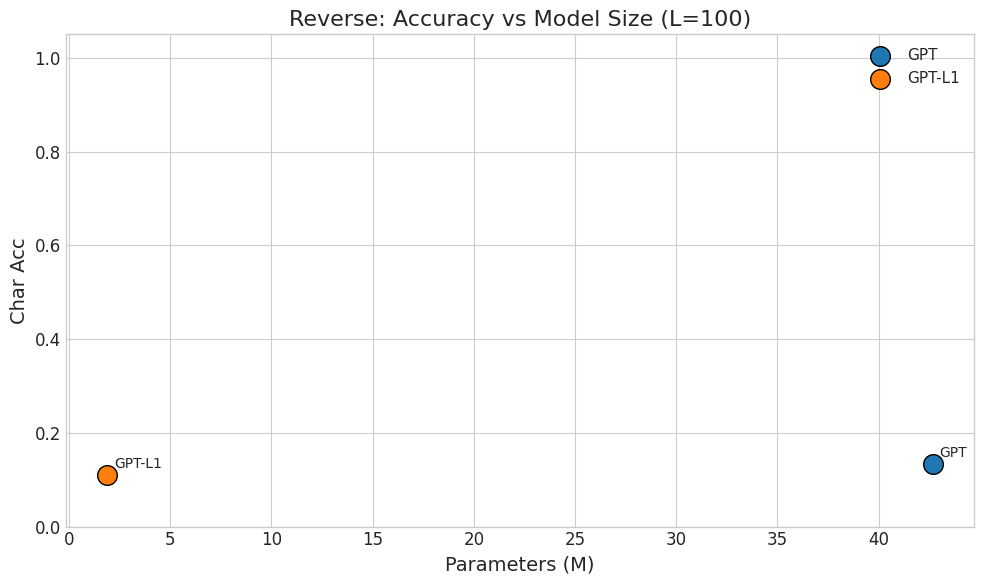

In [49]:
def plot_param_efficiency(df, task, length=100, metric='char_acc'):
    """
    Scatter plot: parameter count vs accuracy.
    Models above the trend line are more parameter-efficient.
    """
    task_df = df[df['task'] == task].copy()
    col = f'L{length}_{metric}'
    
    if col not in task_df.columns or 'param_count_M' not in task_df.columns:
        return None
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for _, row in task_df.iterrows():
        if pd.notna(row.get('param_count_M')) and pd.notna(row.get(col)):
            model = row['model']
            color = MODEL_COLORS.get(model, '#333333')
            label = MODEL_LABELS.get(model, model)
            ax.scatter(row['param_count_M'], row[col], 
                      c=color, s=200, label=label, edgecolors='black', linewidth=1)
            ax.annotate(label, (row['param_count_M'], row[col]), 
                       textcoords="offset points", xytext=(5, 5), fontsize=10)
    
    ax.set_xlabel('Parameters (M)')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{TASK_LABELS.get(task, task)}: Accuracy vs Model Size (L={length})')
    ax.set_ylim([0, 1.05])
    
    # Remove duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='best')
    
    return fig, ax

# Plot for each task
for task in sorted(df['task'].unique()):
    result = plot_param_efficiency(df, task, length=100, metric='char_acc')
    if result:
        plt.tight_layout()
        plt.savefig(f'param_efficiency_{task}.pdf', bbox_inches='tight', dpi=150)
        plt.show()

## 7. Summary Table

Comprehensive results table for the paper.

In [50]:
def create_summary_table(df, metric='char_acc'):
    """Create a summary table suitable for paper publication."""
    
    model_order = ['gpt', 'gpt_level1', 'gpt_level2', 'ut', 'ut_level1', 'ut_level2', 'trm']
    lengths = [20, 40, 60, 80, 100]
    
    summary_data = []
    
    for task in sorted(df['task'].unique()):
        task_df = df[df['task'] == task]
        
        for model in model_order:
            model_df = task_df[task_df['model'] == model]
            if model_df.empty:
                continue
                
            row = model_df.iloc[0]
            
            entry = {
                'Task': TASK_LABELS.get(task, task),
                'Model': MODEL_LABELS.get(model, model),
                'Params (M)': f"{row.get('param_count_M', np.nan):.1f}" if pd.notna(row.get('param_count_M')) else '-',
            }
            
            for L in lengths:
                col = f'L{L}_{metric}'
                if col in row and pd.notna(row[col]):
                    entry[f'L={L}'] = f"{row[col]:.3f}"
                else:
                    entry[f'L={L}'] = '-'
            
            summary_data.append(entry)
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

summary_table = create_summary_table(df, metric='char_acc')
print("Character Accuracy Summary Table:")
display(summary_table)

# Save to CSV for paper
summary_table.to_csv('results_summary.csv', index=False)
print("\nSaved to results_summary.csv")

Character Accuracy Summary Table:


,Task,Model,Params (M),L=20,L=40,L=60,L=80,L=100
0,Addition,GPT,42.7,0.181,0.110,0.099,0.096,0.099
1,Addition,GPT-L1,1.9,0.130,0.106,0.102,0.095,0.096
2,Addition,GPT-L2,1.9,0.117,0.108,0.102,0.097,0.097
3,Addition,UT,1.9,0.938,0.101,0.099,0.097,0.103
4,Addition,UT-L1,1.9,0.845,0.109,0.104,0.101,0.104
5,Addition,UT-L2,1.9,0.123,0.098,0.100,0.098,0.094
6,Addition,TRM,1.9,0.111,0.099,0.100,0.104,0.097
7,Copy,GPT,42.7,0.999,0.096,0.097,0.098,0.101
8,Copy,GPT-L1,1.9,1.000,0.096,0.095,0.098,0.099
9,Copy,GPT-L2,1.9,0.995,0.098,0.097,0.097,0.099



Saved to results_summary.csv


## 8. Training Curves

Compare how different models learn over training steps.

wandb: WARNING A graphql request initiated by the public wandb API timed out (timeout=19 sec). Create a new API with an integer timeout larger than 19, e.g., `api = wandb.Api(timeout=29)` to increase the graphql timeout.


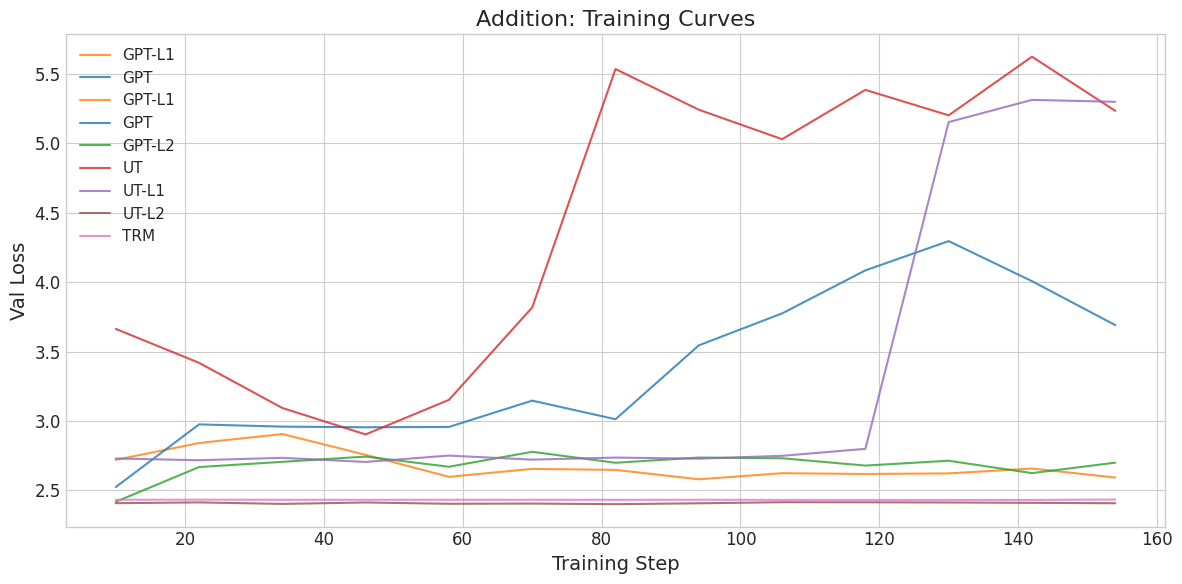

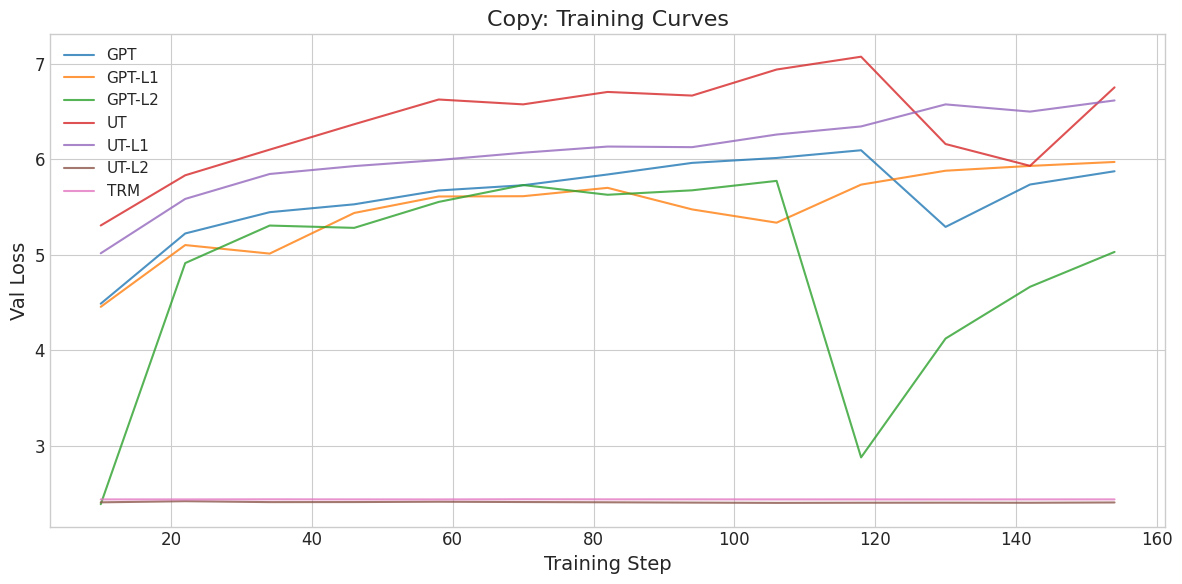

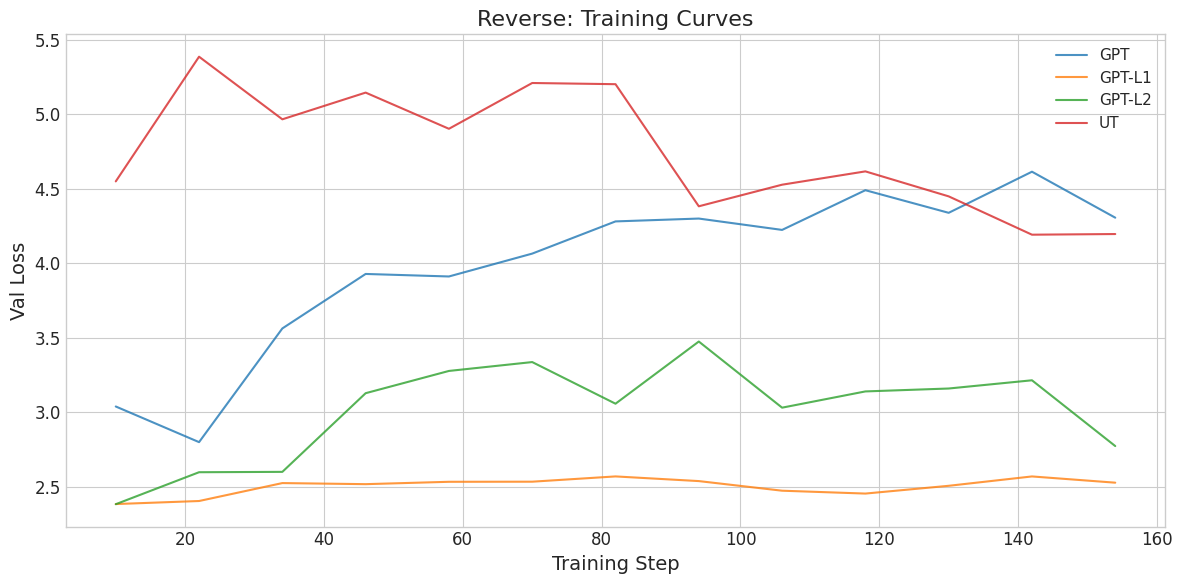

In [51]:
def plot_training_curves(runs, task_filter, metric='val_loss'):
    """Plot training curves for all models on a given task."""
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for run in runs:
        model, task = parse_run_name(run.name)
        if task != task_filter:
            continue
        
        try:
            history = run.history(samples=1000)
            if '_step' in history.columns and metric in history.columns:
                # Filter out NaN values
                valid = history[[metric, '_step']].dropna()
                if not valid.empty:
                    color = MODEL_COLORS.get(model, '#333333')
                    label = MODEL_LABELS.get(model, model)
                    ax.plot(valid['_step'], valid[metric], 
                           label=label, color=color, linewidth=1.5, alpha=0.8)
        except Exception as e:
            print(f"Error loading history for {run.name}: {e}")
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(f'{TASK_LABELS.get(task_filter, task_filter)}: Training Curves')
    ax.legend(loc='best')
    
    return fig, ax

# Plot training curves for each task
for task in sorted(df['task'].unique()):
    plot_training_curves(filtered_runs, task, metric='val_loss')
    plt.tight_layout()
    plt.savefig(f'training_curves_{task}.pdf', bbox_inches='tight', dpi=150)
    plt.show()

## 9. Accuracy Evolution During Training

Track how evaluation accuracy evolves during training for different sequence lengths.

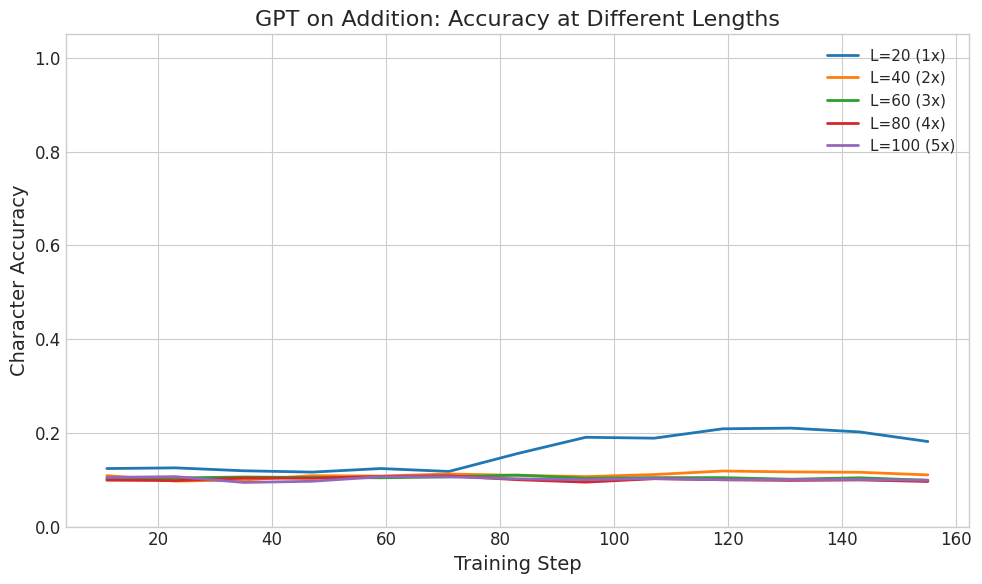

In [53]:
def plot_accuracy_evolution(runs, task_filter, model_filter, lengths=[20, 60, 100]):
    """Plot how accuracy at different lengths evolves during training for a specific model."""
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for run in runs:
        model, task = parse_run_name(run.name)
        if task != task_filter or model != model_filter:
            continue
        
        try:
            history = run.history(samples=2000)
            
            for length in lengths:
                metric = f'TaskEvaluation/{task}/L{length}/char_acc'
                if metric in history.columns and '_step' in history.columns:
                    valid = history[[metric, '_step']].dropna()
                    if not valid.empty:
                        ratio = length // 20
                        ax.plot(valid['_step'], valid[metric], 
                               label=f'L={length} ({ratio}x)', linewidth=2)
        except Exception as e:
            print(f"Error: {e}")
    
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Character Accuracy')
    ax.set_title(f'{MODEL_LABELS.get(model_filter, model_filter)} on {TASK_LABELS.get(task_filter, task_filter)}: Accuracy at Different Lengths')
    ax.legend(loc='best')
    ax.set_ylim([0, 1.05])
    
    return fig, ax

# Example: Plot for GPT on addition task
if 'addition' in df['task'].values and 'gpt' in df['model'].values:
    plot_accuracy_evolution(filtered_runs, 'addition', 'gpt', lengths=[20, 40, 60, 80, 100])
    plt.tight_layout()
    plt.savefig('accuracy_evolution_gpt_addition.pdf', bbox_inches='tight', dpi=150)
    plt.show()

## 10. Overall Model Rankings

Rank models by their average performance across tasks and lengths.

Model Rankings (by Overall Mean Accuracy):



,Model,Overall Mean,Train (1x) Mean,Generalization (3x+) Mean,Param Count (M)
3,UT,0.273,0.969,0.099,1.893
4,UT-L1,0.265,0.922,0.100,1.889
1,GPT,0.246,0.723,0.119,42.669
0,GPT-L1,0.222,0.700,0.101,1.883
2,GPT-L2,0.191,0.556,0.098,1.892
5,UT-L2,0.100,0.107,0.098,1.885
6,TRM,0.099,0.109,0.098,1.885


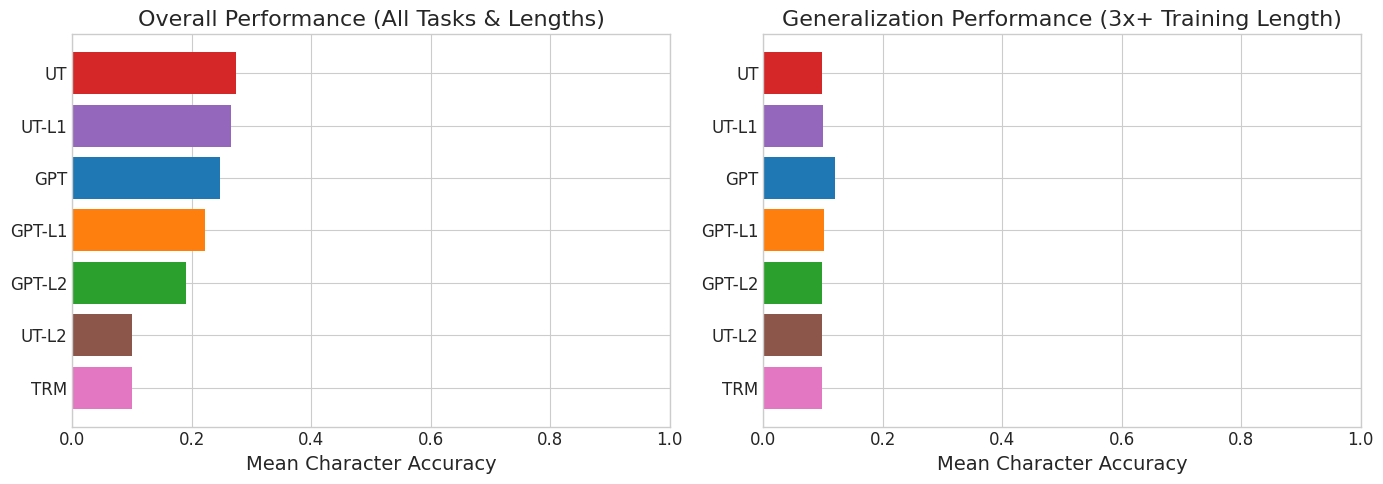

In [54]:
def compute_model_rankings(df, metric='char_acc'):
    """Compute overall model rankings based on various criteria."""
    
    lengths = [20, 40, 60, 80, 100]
    
    rankings = []
    
    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        
        # Collect all accuracy values
        all_accs = []
        train_accs = []  # L=20 (1x)
        gen_accs = []    # L>=60 (3x+)
        
        for _, row in model_df.iterrows():
            for L in lengths:
                col = f'L{L}_{metric}'
                if col in row and pd.notna(row[col]):
                    all_accs.append(row[col])
                    if L == 20:
                        train_accs.append(row[col])
                    if L >= 60:
                        gen_accs.append(row[col])
        
        if all_accs:
            rankings.append({
                'Model': MODEL_LABELS.get(model, model),
                'model_key': model,
                'Overall Mean': np.mean(all_accs),
                'Train (1x) Mean': np.mean(train_accs) if train_accs else np.nan,
                'Generalization (3x+) Mean': np.mean(gen_accs) if gen_accs else np.nan,
                'Param Count (M)': model_df['param_count_M'].iloc[0] if 'param_count_M' in model_df.columns else np.nan,
            })
    
    rank_df = pd.DataFrame(rankings)
    rank_df = rank_df.sort_values('Overall Mean', ascending=False)
    
    return rank_df

rankings = compute_model_rankings(df, metric='char_acc')

if not rankings.empty:
    print("Model Rankings (by Overall Mean Accuracy):\n")
    display(rankings[['Model', 'Overall Mean', 'Train (1x) Mean', 'Generalization (3x+) Mean', 'Param Count (M)']].round(3))
    
    # Bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall performance
    ax1 = axes[0]
    colors = [MODEL_COLORS.get(m, '#333333') for m in rankings['model_key']]
    ax1.barh(rankings['Model'], rankings['Overall Mean'], color=colors)
    ax1.set_xlabel('Mean Character Accuracy')
    ax1.set_title('Overall Performance (All Tasks & Lengths)')
    ax1.set_xlim([0, 1])
    ax1.invert_yaxis()
    
    # Generalization performance
    ax2 = axes[1]
    ax2.barh(rankings['Model'], rankings['Generalization (3x+) Mean'], color=colors)
    ax2.set_xlabel('Mean Character Accuracy')
    ax2.set_title('Generalization Performance (3x+ Training Length)')
    ax2.set_xlim([0, 1])
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('model_rankings.pdf', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Not enough data for rankings.")

## 11. Key Findings Summary

In [55]:
def generate_key_findings(df, deg_df, rankings):
    """Generate automated key findings based on the data."""
    
    findings = []
    
    # 1. Best overall model
    if not rankings.empty:
        best_overall = rankings.iloc[0]
        findings.append(f"**Best Overall Model**: {best_overall['Model']} with {best_overall['Overall Mean']:.1%} mean accuracy across all tasks and lengths.")
    
    # 2. Best generalizing model
    if not rankings.empty and 'Generalization (3x+) Mean' in rankings.columns:
        gen_rankings = rankings.sort_values('Generalization (3x+) Mean', ascending=False)
        best_gen = gen_rankings.iloc[0]
        findings.append(f"**Best Generalization**: {best_gen['Model']} maintains {best_gen['Generalization (3x+) Mean']:.1%} accuracy at 3x+ training length.")
    
    # 3. Most parameter-efficient
    if not rankings.empty and 'Param Count (M)' in rankings.columns:
        # Compute accuracy per million parameters
        rankings_copy = rankings.copy()
        rankings_copy['efficiency'] = rankings_copy['Overall Mean'] / rankings_copy['Param Count (M)']
        most_efficient = rankings_copy.sort_values('efficiency', ascending=False).iloc[0]
        findings.append(f"**Most Parameter Efficient**: {most_efficient['Model']} ({most_efficient['Param Count (M)']:.1f}M params)")
    
    # 4. Task-specific insights
    if not deg_df.empty:
        for task in deg_df['task'].unique():
            task_deg = deg_df[deg_df['task'] == task]
            if not task_deg.empty:
                best_retention = task_deg.sort_values('retention_ratio', ascending=False).iloc[0]
                findings.append(f"**{TASK_LABELS.get(task, task)}**: {MODEL_LABELS.get(best_retention['model'], best_retention['model'])} has best retention ({best_retention['retention_ratio']:.1%} at 5x length)")
    
    return findings

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

if 'deg_df' in dir() and 'rankings' in dir():
    findings = generate_key_findings(df, deg_df, rankings)
    for i, finding in enumerate(findings, 1):
        print(f"\n{i}. {finding}")
else:
    print("Run all cells above to generate key findings.")

print("\n" + "=" * 60)
print("Figures saved:")
print("  - length_generalization_char_acc.pdf")
print("  - length_generalization_seq_acc.pdf")
print("  - model_task_heatmaps.pdf")
print("  - degradation_analysis.pdf")
print("  - param_efficiency_{task}.pdf")
print("  - training_curves_{task}.pdf")
print("  - model_rankings.pdf")
print("  - results_summary.csv")
print("=" * 60)

KEY FINDINGS

1. **Best Overall Model**: UT with 27.3% mean accuracy across all tasks and lengths.

2. **Best Generalization**: GPT maintains 11.9% accuracy at 3x+ training length.

3. **Most Parameter Efficient**: UT (1.9M params)

4. **Addition**: TRM has best retention (87.4% at 5x length)

5. **Copy**: UT-L2 has best retention (104.3% at 5x length)

6. **Reverse**: GPT has best retention (13.6% at 5x length)

Figures saved:
  - length_generalization_char_acc.pdf
  - length_generalization_seq_acc.pdf
  - model_task_heatmaps.pdf
  - degradation_analysis.pdf
  - param_efficiency_{task}.pdf
  - training_curves_{task}.pdf
  - model_rankings.pdf
  - results_summary.csv


---

- Do not forget to inspect different quantiles at different lengths.

- For the short-run, add some more experiments now.

- Also try to understand how come it's the case that there are these big training curve shifts there. [some sort of phase transition]

---
# TO DO:

- Build a "better for the ``beginning'' vs ``middle'' etc by looking at the character and using them as operational ways to measure different things.
- Build compute-iso frontiers (x-axis FLOPs training and then x-axis FLOPs inference), and y-axis is performance.
- Start with x-axis being trainign FLOPs)

run1.history(pandas=True)

In [60]:
df_run1 = run1.history(pandas=True)

In [62]:
df_run1.columns.tolist()

['TaskEvaluation/addition/L100/first_char_acc',
 'TaskEvaluation/addition/L40/seq_acc',
 '_step',
 'TaskEvaluation/addition/L60/pos_q2_acc',
 'TaskEvaluation/addition/L100/seq_acc',
 'TaskEvaluation/addition/L20/pos_q1_acc',
 'TaskEvaluation/addition/L80/first_char_acc',
 'model/param_count',
 'epoch',
 'TaskEvaluation/addition/L60/last_char_acc',
 'TaskEvaluation/addition/L20/char_acc',
 'TaskEvaluation/addition/L60/pos_q4_acc',
 '_timestamp',
 'TaskEvaluation/addition/L60/pos_q3_acc',
 'TaskEvaluation/addition/L20/last_char_acc',
 'TaskEvaluation/addition/L40/last_char_acc',
 'TaskEvaluation/addition/L80/char_acc',
 'TaskEvaluation/addition/L80/pos_q1_acc',
 'TaskEvaluation/addition/L80/pos_q2_acc',
 '_runtime',
 'TaskEvaluation/addition/L40/char_acc',
 'TaskEvaluation/addition/L80/pos_q3_acc',
 'TaskEvaluation/addition/L20/first_char_acc',
 'TaskEvaluation/addition/L60/first_char_acc',
 'trainer/global_step',
 'TaskEvaluation/addition/L60/pos_q1_acc',
 'TaskEvaluation/addition/L60/s